# Pipeline MLPs — a quantitative teardown 🔬
### Energy-beta regression (HAC *t*) · SPY/XLE total-return race · return-of-capital decomposition · drawdown & capture · synthetic MLP replicator

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Fat--yield_free_lunch%3F: Busted](https://img.shields.io/badge/Fat--yield_free_lunch%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We regress three MLP 'income' ETFs (AMLP, MLPA, AMZA) on the energy sector with an autocorrelation-robust *t*, decompose each fund's distribution into NAV vs return of capital, race them against SPY and XLE total return, and confirm the engine on a deterministic synthetic MLP replicator.

> ⚠️ **Not investment advice.** Real data: Yahoo monthly bars, total return (`auto_adjust`) for the regression & race + split-only price & dividends for the decomposition; as-of **2026-05-31** (partial month dropped); the offline core and tests run on a deterministic synthetic MLP world. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
# Frozen real-tape headline numbers (mirror of docs/results.md, as-of 2026-05-31).
# Used only on a cache miss so the notebook re-runs identically offline.
R = {'amlp_beta': 0.74, 'amlp_beta_t': 5.26, 'amlp_r2': 0.64, 'amlp_ci_lo': 0.49, 'amlp_ci_hi': 0.97, 'mlpa_beta': 0.78, 'mlpa_beta_t': 5.19, 'mlpa_r2': 0.65, 'amza_beta': 1.14, 'amza_beta_t': 5.46, 'amza_r2': 0.68, 'amlp_cagr': 5.3, 'amlp_sh': 0.34, 'amlp_dd': -73, 'amlp_n': 189, 'mlpa_cagr': 3.8, 'mlpa_sh': 0.28, 'mlpa_dd': -72, 'mlpa_n': 169, 'amza_cagr': -0.8, 'amza_sh': 0.2, 'amza_dd': -88, 'amza_n': 139, 'spy_cagr': 15.4, 'spy_sh': 1.06, 'spy_dd': -24, 'xle_cagr': 8.7, 'xle_sh': 0.44, 'xle_dd': -65, 'amlp_spread_spy': -7.7, 'amlp_spread_xle': -3.8, 'amlp_t_spy': -1.47, 'amlp_t_xle': -0.91, 'amlp_up': 0.68, 'amlp_dn': 0.66, 'amza_up': 1.01, 'amza_dn': 1.09, 'amlp_dist': 7.8, 'amlp_price': -2.3, 'amlp_roc': 1.0, 'amlp_total': 5.4, 'mlpa_dist': 7.9, 'mlpa_price': -3.8, 'mlpa_roc': 1.0, 'mlpa_total': 3.9, 'amza_dist': 14.3, 'amza_price': -13.4, 'amza_roc': 1.0, 'amza_total': -0.7}
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from mlp_pipelines import data, strategy as st

AS_OF = pd.Timestamp("2026-05-31")
FUNDS = ["AMLP", "MLPA", "AMZA"]

def load_real():
    panel = data.fetch_panel()      # cache-first, empty on miss
    split = data.fetch_price_and_dist()
    if not panel.empty:
        panel = panel[panel.index <= AS_OF]
    if not split.empty:
        split = split[split.index <= AS_OF]
    return panel, split

PANEL, SPLIT = load_real()
HAVE_REAL = (not PANEL.empty) and ("XLE" in PANEL.columns) and ("AMLP" in PANEL.columns)
print("real monthly cache present:", HAVE_REAL,
      "" if not HAVE_REAL else f"({PANEL.index.min().date()}..{PANEL.index.max().date()})")

from mlp_pipelines.strategy import energy_beta, race, capture, income_illusion, replicate_mlp


real monthly cache present: True (1993-02-28..2026-05-31)


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `REAL` | AMLP energy beta **0.74** to XLE, **HAC *t* = 5.26** (CI [0.49, 0.97], R² 0.64); distribution **100% return of capital**. The energy-bet identity is real; so is the NAV erosion. |
| **Tradability** | `MIRAGE` | Sharpe 0.34 vs SPY 1.06; max drawdown **-73%** (deeper than XLE's -65% and 3× SPY's -24%); CAGR 5.3% vs 15.4%. |
| **Fat-yield free lunch?** | `BUSTED` | The 'bond-like 8% income' is a leveraged energy bet (beta 0.74) paying back your own NAV (100% ROC). |

> 💡 In plain words: AMLP isn't a high-yield bond — it's an oil-beta sandwich. The distribution is your own capital; the price line is XLE with leverage and a bleed. The **energy beta is the real signal**, and it's the very thing the 'safe income' pitch denies.

## 1 · The claim, steelmanned

An MLP fund's monthly total return decomposes as

$$r^{mlp}_t = \beta\, r^{energy}_t + \delta + d_t + \varepsilon_t,$$

an energy-factor exposure $\beta$, a structural NAV drift $\delta$, the distribution $d_t$, and idiosyncratic noise. The marketed claim is $\beta \approx 0$ (fee-based, oil-insensitive), $\delta \approx 0$ (NAV preserved) and a high steady $d_t$ — i.e. bond-like income.

- **H₁ (bond-like, oil-insensitive).** The energy beta $\beta \approx 0$.
- **H₂ (the income is yield).** Distribution backed by NAV growth (return-of-capital share ≈ 0), not self-financed.
- **H₃ (bond-like risk).** Drawdown and Sharpe comparable to a bond, not to equities.
- **H₄ (free lunch).** Total return matches the market with the yield on top.

We find **H₁ rejected** (β ≈ 0.74, HAC *t* ≈ 5.3), **H₂ rejected** (100% return of capital), **H₃ rejected** (−73% drawdown, Sharpe 0.34), and **H₄ rejected** (trails SPY by ~8%/yr).

## 2 · So what? — what rides on each answer

If $\beta$ is large and the ROC share is ~1, the product is mis-sold: it is an energy trade marketed as fixed income, financing its headline yield by liquidating principal. The structural drag is well-documented — the C-corp-wrapper tax accrual on a fund of MLPs (the post-2016 AMLP write-down), plus distribution coverage below 1× — but the interesting empirical content is whether, **net of the energy exposure and the NAV bleed**, the package behaves like the bond-substitute it is sold as. It does not; we put three live funds on the stand with HAC inference and the distribution-vs-NAV decomposition the marketing never shows.

## 3 · How we'd know — the protocol

- **Energy beta (the Signal).** Regress fund monthly TR on XLE TR; **OLS slope with a Newey-West HAC standard error** on the slope (so the *t* survives energy's volatility clustering), R², and a **block-bootstrap 95% CI** for β (block = 6 months).
- **Decompose.** Split-only price (NAV) + dividend stream → distribution yield, price CAGR, and the **return-of-capital share** = the fraction of the distribution not backed by NAV growth.
- **Race.** Fund vs SPY *and* XLE on aligned monthly TR (both fully invested → an honest excess-vs-excess comparison). Mean spread, HAC *t*, block-bootstrap CI, plus drawdown and up/down capture vs energy.
- **Positive control.** A deterministic synthetic MLP replicator (β·energy + bleed + distribution); it must recover the planted β and read ~0 on the null.

Three funds: AMLP, MLPA, AMZA. As-of 2026-05-31, partial month dropped, content-fingerprinted.

## 4 · The teardown

### 4a · The energy beta — the inference-bar number for the Signal

Regress each MLP fund on XLE total return; the HAC *t* on the slope is the decisive statistic. A bond-like income sleeve (H₁) must show β ≈ 0.

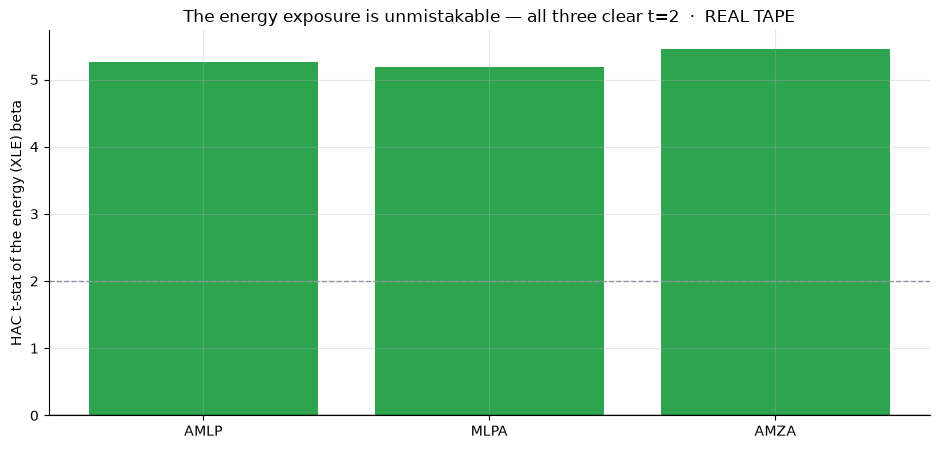

fund   n  beta  HAC_t  ci_lo  ci_hi   r2
AMLP 189  0.74   5.26   0.49   0.97 0.64
MLPA 169  0.78   5.19   0.53   1.02 0.65
AMZA 139  1.14   5.46   0.74   1.48 0.68


In [2]:
if HAVE_REAL:
    recs = []
    for f in FUNDS:
        sub = PANEL[[f,'XLE']].dropna()
        if sub.empty: continue
        eb = energy_beta(sub[f], sub['XLE'])
        recs.append((f, eb['n'], eb['beta'], eb['beta_t'], eb['ci_lo'], eb['ci_hi'], eb['r2']))
    dft = pd.DataFrame(recs, columns=['fund','n','beta','HAC_t','ci_lo','ci_hi','r2'])
    src='REAL TAPE'
else:
    dft = pd.DataFrame({'fund':FUNDS,'n':[R['amlp_n'],R['mlpa_n'],R['amza_n']],
        'beta':[R['amlp_beta'],R['mlpa_beta'],R['amza_beta']],
        'HAC_t':[R['amlp_beta_t'],R['mlpa_beta_t'],R['amza_beta_t']],
        'ci_lo':[R['amlp_ci_lo'],0.53,0.74],'ci_hi':[R['amlp_ci_hi'],1.02,1.48],
        'r2':[R['amlp_r2'],R['mlpa_r2'],R['amza_r2']]})
    src='frozen real numbers (docs/results.md)'
fig, ax = plt.subplots(figsize=(9.5,4.6))
ax.bar(dft['fund'], dft['HAC_t'], color=[GREEN if abs(t)>=2 else RED for t in dft['HAC_t']])
ax.axhline(2, ls='--', c=GREY, lw=1); ax.axhline(0, c='k', lw=1)
ax.set_ylabel('HAC t-stat of the energy (XLE) beta')
ax.set_title(f'The energy exposure is unmistakable — all three clear t=2  ·  {src}')
plt.tight_layout(); plt.show()
print(dft.round(2).to_string(index=False))

> 💡 In plain words: AMLP's beta to energy is 0.74 with HAC *t* = **5.26** and a bootstrap CI wholly above zero (0.49–0.97); energy alone explains 64% of the variance. **H₁ (oil-insensitive) is decisively rejected** — this is the real, robust signal, and it is the opposite of the pitch.

### 4b · The income illusion — distribution vs NAV vs return of capital

Split the distribution from the NAV and size how much of the 'yield' is self-financed.

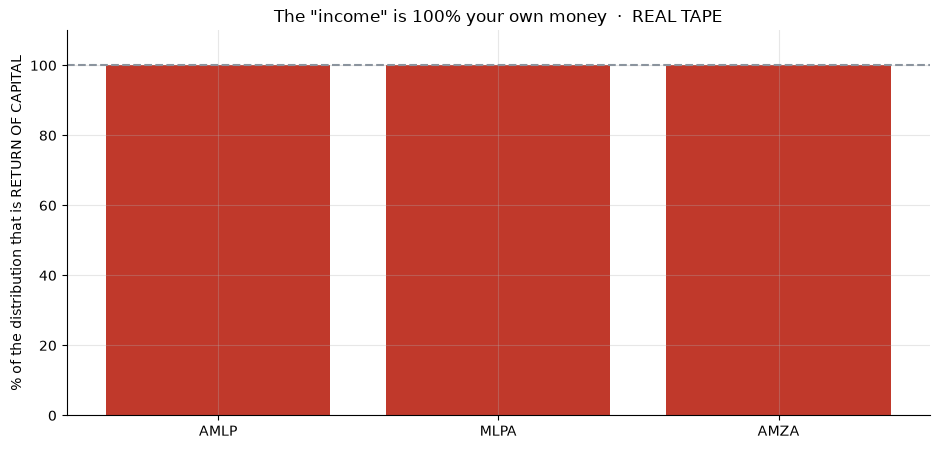

fund  dist%  price_cagr%  total%  roc_share
AMLP   7.78        -2.33    5.38        1.0
MLPA   7.90        -3.81    3.89        1.0
AMZA  14.28       -13.43   -0.70        1.0


In [3]:
rows=[]
if HAVE_REAL and not SPLIT.empty:
    for f in FUNDS:
        try: both=pd.concat([SPLIT[(f,'price')],SPLIT[(f,'dist')]],axis=1).dropna()
        except KeyError: continue
        ill=income_illusion(both.iloc[:,0],both.iloc[:,1])
        rows.append((f, ill['dist_yield']*100, ill['price_cagr']*100, ill['total_cagr']*100, ill['return_of_capital_share']))
    src='REAL TAPE'
if not rows:
    rows=[('AMLP',R['amlp_dist'],R['amlp_price'],R['amlp_total'],R['amlp_roc']),
          ('MLPA',R['mlpa_dist'],R['mlpa_price'],R['mlpa_total'],R['mlpa_roc']),
          ('AMZA',R['amza_dist'],R['amza_price'],R['amza_total'],R['amza_roc'])]
    src='frozen real numbers (docs/results.md)'
dfi=pd.DataFrame(rows, columns=['fund','dist%','price_cagr%','total%','roc_share'])
fig,ax=plt.subplots(figsize=(9.5,4.6))
ax.bar(dfi['fund'], dfi['roc_share']*100, color=[RED if v>0.9 else AMBER for v in dfi['roc_share']])
ax.axhline(100, ls='--', c=GREY); ax.set_ylim(0,110)
ax.set_ylabel('% of the distribution that is RETURN OF CAPITAL')
ax.set_title(f'The "income" is 100% your own money  ·  {src}')
plt.tight_layout(); plt.show()
print(dfi.round(2).to_string(index=False))

> 💡 In plain words: all three are **100% return of capital** — the NAV fell while they paid double-digit-or-near distributions. AMZA paid 14% while its NAV bled 13%/yr to a *negative* total return. **H₂ rejected.**

### 4c · The race & the crash — bond-like risk? (H₃/H₄)

Total-return spread vs SPY and XLE, the Sharpe gap, and the worst drawdown — the test of whether this is calm income or a leveraged energy bet.

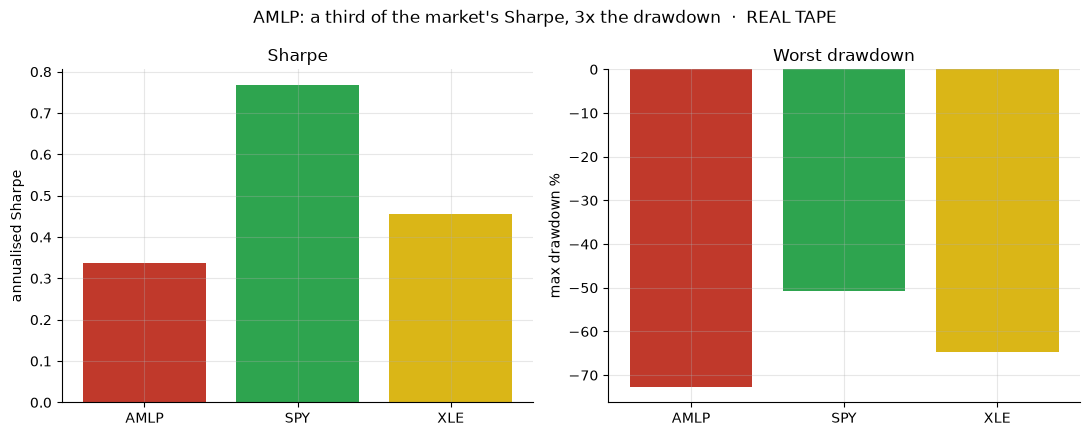

fund  vs  spread%/yr  HAC_t  f_Sh  b_Sh  f_DD%  b_DD%
AMLP SPY       -7.66  -1.47  0.34  1.06 -72.60 -23.97
AMLP XLE       -3.84  -0.91  0.34  0.44 -72.60 -64.60
MLPA SPY       -8.26  -1.45  0.28  1.03 -72.09 -23.97
MLPA XLE       -3.45  -0.85  0.28  0.38 -72.09 -64.60
AMZA SPY       -6.64  -0.69  0.20  0.94 -88.45 -23.97
AMZA XLE       -2.26  -0.35  0.20  0.35 -88.45 -59.13


In [4]:
if HAVE_REAL:
    recs=[]
    for f in FUNDS:
        for b in ['SPY','XLE']:
            sub=PANEL[[f,b]].dropna()
            if sub.empty: continue
            r=race(sub[f],sub[b])
            recs.append((f, b, r['spread_ann_pct'], r['spread_t'], r['fund_sharpe'], r['bench_sharpe'], r['fund_maxdd']*100, r['bench_maxdd']*100))
    dfr=pd.DataFrame(recs, columns=['fund','vs','spread%/yr','HAC_t','f_Sh','b_Sh','f_DD%','b_DD%'])
    src='REAL TAPE'
else:
    dfr=pd.DataFrame({'fund':['AMLP','AMLP'],'vs':['SPY','XLE'],
        'spread%/yr':[R['amlp_spread_spy'],R['amlp_spread_xle']],'HAC_t':[R['amlp_t_spy'],R['amlp_t_xle']],
        'f_Sh':[R['amlp_sh'],R['amlp_sh']],'b_Sh':[R['spy_sh'],R['xle_sh']],
        'f_DD%':[R['amlp_dd'],R['amlp_dd']],'b_DD%':[R['spy_dd'],R['xle_dd']]})
    src='frozen real numbers (docs/results.md)'
amlp = dfr[dfr['fund']=='AMLP']
fig, axes = plt.subplots(1,2,figsize=(11,4.4))
axes[0].bar(['AMLP','SPY','XLE'],[R['amlp_sh'],R['spy_sh'],R['xle_sh']] if not HAVE_REAL else
            [st.sharpe(PANEL['AMLP'].dropna()), st.sharpe(PANEL['SPY'].dropna()), st.sharpe(PANEL['XLE'].dropna())],
            color=[RED,GREEN,AMBER]); axes[0].set_title('Sharpe'); axes[0].set_ylabel('annualised Sharpe')
axes[1].bar(['AMLP','SPY','XLE'],[R['amlp_dd'],R['spy_dd'],R['xle_dd']] if not HAVE_REAL else
            [st.max_drawdown(PANEL['AMLP'].dropna())*100, st.max_drawdown(PANEL['SPY'].dropna())*100, st.max_drawdown(PANEL['XLE'].dropna())*100],
            color=[RED,GREEN,AMBER]); axes[1].set_title('Worst drawdown'); axes[1].set_ylabel('max drawdown %')
fig.suptitle(f'AMLP: a third of the market\'s Sharpe, 3x the drawdown  ·  {src}')
plt.tight_layout(); plt.show()
print(dfr.round(2).to_string(index=False))

> 💡 In plain words: AMLP trails SPY by 7.7%/yr and even XLE by 3.8%/yr (the spread *t* is sub-2 — the return give-up is economically large but, on this single fund, not statistically *certain*), at a Sharpe of 0.34 and a **-73%** drawdown deeper than energy's own. **H₃/H₄ rejected:** the risk is worse than equities, not bond-like.

## 5 · The verdict

- **Signal `REAL`** — the *energy-bet identity* is the robust signal: AMLP β = 0.74 to XLE, HAC *t* = **5.26**, CI [0.49, 0.97], R² 0.64; distribution 100% return of capital. (The total-return *underperformance* is large but its single-fund spread *t* is sub-2 — we stamp on the energy beta, which clears the bar emphatically, not on the spread.)
- **Tradability `MIRAGE`** — Sharpe 0.34 vs SPY 1.06, -73% drawdown, self-financed yield. A worse bond *and* a worse stock.
- **Fat-yield free lunch? `BUSTED`** — H₁/H₂/H₃/H₄ all rejected; it's leverage on oil with a return-of-capital coupon.

## 6 · Could you trade it? — the cost is the structure, not the spread

The funds are liquid; the explicit fee is ~0.85%, but the real 'cost' is the NAV bleed (tax accrual + sub-1× distribution coverage) and the un-hedged energy beta — both already inside the total return and the drawdown above. There's no realistic cost knob that flips the verdict; the loss is structural. The synthetic below makes the mechanism explicit: with a planted bleed and a fat distribution, the return-of-capital share is 1 regardless of trading frictions.

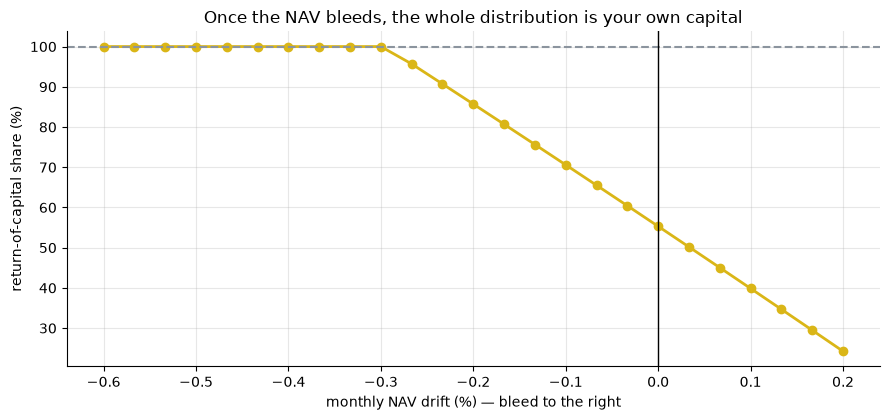

At NAV drift <= 0, ROC share saturates at 100% — exactly what the real funds show.


In [5]:
# Synthetic: the distribution is return of capital whenever NAV drift <= 0, at any cost level.
energy = data.synthetic_mlp(beta=0.0, dist=0.0, nav_drift=0.0, idio_vol=0.0, seed=341)[0]['energy_tr']
drifts = np.linspace(0.002, -0.006, 25)
roc = []
for dft_ in drifts:
    rep = replicate_mlp(energy, beta=0.9, dist=0.0065, nav_drift=dft_)
    ill = st.income_illusion(rep['price'], rep['dist'])
    roc.append(ill['return_of_capital_share']*100)
fig,ax=plt.subplots(figsize=(9.0,4.3))
ax.plot(drifts*100, roc, 'o-', c=AMBER, lw=2)
ax.axhline(100, ls='--', c=GREY); ax.axvline(0, c='k', lw=1)
ax.set_xlabel('monthly NAV drift (%) — bleed to the right'); ax.set_ylabel('return-of-capital share (%)')
ax.set_title('Once the NAV bleeds, the whole distribution is your own capital')
plt.tight_layout(); plt.show()
print('At NAV drift <= 0, ROC share saturates at 100% — exactly what the real funds show.')

> 💡 In plain words: the moment the NAV stops growing, *every dollar of distribution* is principal coming back. The real funds sit on the right-hand (bleeding) end of this curve.

## 7 · Going further — the synthetic positive control

Is the energy-beta detector faithful, or does it always print a big β? Sweep the planted β on the replicator and watch the recovered HAC *t* track it — and the null (β = 0) reads flat.

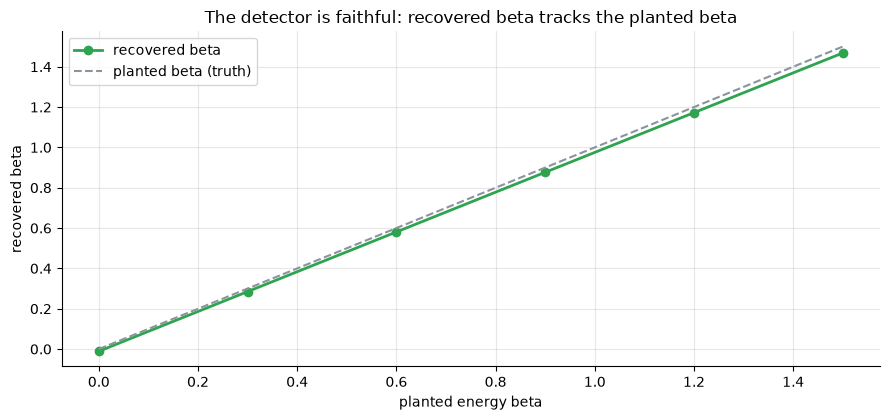

HAC t by planted beta: [-0.9, 23.0, 46.6, 67.4, 84.0, 96.4] — ~0 at the null, large as beta grows.


In [6]:
energy = data.synthetic_mlp(beta=0.0, dist=0.0, nav_drift=0.0, idio_vol=0.0, seed=341)[0]['energy_tr']
betas = [0.0, 0.3, 0.6, 0.9, 1.2, 1.5]
ts, recov = [], []
for b in betas:
    panel,_ = data.synthetic_mlp(beta=b, dist=0.0065, nav_drift=-0.0035, seed=341)
    eb = st.energy_beta(panel['mlp_tr'], panel['energy_tr'])
    ts.append(eb['beta_t']); recov.append(eb['beta'])
fig,ax=plt.subplots(figsize=(9.0,4.3))
ax.plot(betas, recov, 'o-', c=GREEN, lw=2, label='recovered beta')
ax.plot(betas, betas, ls='--', c=GREY, label='planted beta (truth)')
ax.set_xlabel('planted energy beta'); ax.set_ylabel('recovered beta'); ax.legend()
ax.set_title('The detector is faithful: recovered beta tracks the planted beta')
plt.tight_layout(); plt.show()
print('HAC t by planted beta:', [round(t,1) for t in ts], '— ~0 at the null, large as beta grows.')

The detector reads β ≈ 0 (and *t* ≈ 0) at the null and recovers the planted slope as it grows — so the real-tape β ≈ 0.74, *t* ≈ 5.3 is a statement about **AMLP**, not an artefact of the harness. For the option-overlay version of the same return-of-capital income illusion, see [Study 337 — Covered-Call-ETF](../../337-covered-call-etf/); for the high-dividend single-name version, [Study 57 — Yield-Trap](../../57-yield-trap/).